# Random Forest (Bosques Aleatorios)

## ¿Qué es un Bosque Aleatorio?

Un **Random Forest** o **Bosque Aleatorio** es un algoritmo de aprendizaje supervisado que combina múltiples **árboles de decisión** para crear un modelo más robusto y preciso. Pertenece a la familia de métodos de **ensemble learning** (aprendizaje por conjuntos).

### Analogía simple:
> "Un árbol de decisión es como la opinión de un experto. Un bosque aleatorio es como reunir a 100 expertos y votar para tomar la mejor decisión."

---

## ¿Cómo funciona?

### 1. Creación del Bosque
Se generan muchos árboles de decisión (por defecto, 100 en scikit-learn). Cada árbol se entrena de manera **aleatoria**:

| Técnica de aleatoriedad | Descripción |
|------------------------|-------------|
| **Bootstrap (muestreo con reemplazo)** | Cada árbol se entrena con una muestra aleatoria del conjunto original (aprox. 2/3 de los datos). |
| **Muestreo aleatorio de características** | En cada división del árbol, solo se considera un subconjunto aleatorio de las características. |

### 2. Predicción
- **Clasificación:** Cada árbol "vota" por una clase. Gana la clase con más votos (moda).
- **Regresión:** Se promedian las predicciones de todos los árboles (media).

### 3. Out-of-Bag (OOB) Error
Alrededor del 1/3 de los datos **no** se usan para entrenar cada árbol (llamados "out-of-bag"). Estos sirven como validación interna gratuita.

---

## Arquitectura visual


------------------------------------------------------

## Explicación del código Pandas

El código utiliza la librería `pandas` para cargar un archivo CSV y realizar muestreos aleatorios con reemplazo.

### Carga de datos
```python
import pandas as pd
personas = pd.read_csv("ingresos.csv")

In [2]:
import pandas as pd
personas = pd.read_csv("ingresos.csv")
print(personas.sample(frac=2/3, replace = True))

print(personas.sample(frac=2/3, replace = True))

print(personas.sample(frac=2/3, replace = True))
print(personas.sample(frac=2/3, replace = True))


print(personas.sample(frac=2/3, replace = True))

    edad  estudio  genero  tipo_trabajo  horas  ingreso
66    21        9       0             0     40        0
20    58        4       1             1     40        0
96    20       10       0             0     25        0
99    47        9       1             0     12        0
98    37        9       1             0     45        0
..   ...      ...     ...           ...    ...      ...
52    35        9       1             1     60        0
59    42        9       1             0     40        0
51    62        9       0             1     30        0
1     30        9       0             0     40        0
18    17        8       1             0     15        0

[67 rows x 6 columns]
    edad  estudio  genero  tipo_trabajo  horas  ingreso
90    59        9       0             0     35        0
2     34        8       0             0     40        0
75    50        9       1             1     40        0
42    24        9       1             0     40        0
38    47        9       1

Se importa la función sample del módulo random de Python estándar.
Nota importante: Esta función no se está utilizando en el código mostrado (no hay ninguna llamada a sample() después).
La función random.sample() se usa para seleccionar elementos aleatorios de una lista sin reemplazo, pero aquí nunca se invoca.

In [3]:
from random import sample


print(personas.columns[:-1], "\n")

Index(['edad', 'estudio', 'genero', 'tipo_trabajo', 'horas'], dtype='object') 



## Descripción de la celda

Esta celda crea, entrena y evalúa un modelo de **Random Forest (Bosque Aleatorio)** para clasificar si una persona tiene un ingreso alto o no.

### Importaciones:
- `RandomForestClassifier` de `sklearn.ensemble` → el clasificador de bosque aleatorio.

### Configuración del modelo:

| Parámetro | Valor | Significado |
|-----------|-------|-------------|
| `n_estimators` | 100 | Número de árboles en el bosque |
| `criterion` | "gini" | Medida de impureza para dividir nodos (también puede ser "entropy") |
| `max_features` | "sqrt" | Número de características a considerar en cada división (raíz cuadrada del total) |
| `bootstrap` | True | Usa muestreo con reemplazo para cada árbol |
| `max_samples` | 2/3 | Cada árbol usa el 66.66% de los datos (muestreo bootstrap) |
| `oob_score` | True | Calcula el error out-of-bag (con los datos no usados en bootstrap) |

### Entrenamiento:
```python
bosque.fit(personas[personas.columns[:-1]].values, personas["ingreso"].values)

In [4]:
from sklearn.ensemble import RandomForestClassifier

bosque = RandomForestClassifier(n_estimators=100,

                                  criterion="gini",

                                  max_features="sqrt",

                                  bootstrap = True,

                                  max_samples=2/3,

                                  oob_score=True)
bosque.fit(personas[personas.columns[:-1]].values, personas["ingreso"].values)


print(bosque.predict([[50, 16, 1, 1, 40]]))

print(bosque.score(personas [personas.columns[:-1]].values, personas ["ingreso"].values))
print(bosque.oob_score_)

[1]
0.99
0.79


## Descripción de la celda

Esta celda visualiza todos los árboles de decisión que componen un modelo de bosque aleatorio (`Random Forest`).

### Importaciones:
- `matplotlib.pyplot` como `plt` → para mostrar los gráficos.
- `sklearn.tree` → para la función `plot_tree` que dibuja árboles de decisión.

### Proceso:
1. Itera sobre cada árbol dentro de `bosque.estimators_` (la lista de árboles del bosque aleatorio).
2. Por cada árbol, usa `tree.plot_tree()` para dibujar su estructura.
3. `feature_names=personas.columns[:-1]` → usa todas las columnas del DataFrame **excepto la última** como nombres de las características.
4. `plt.show()` → muestra el gráfico de cada árbol.

### Salida:
Se abrirán tantas ventanas o figuras como árboles tenga el bosque (por ejemplo, 100 ventanas si `n_estimators=100`).

### Comportamiento:
- Cada árbol se muestra **uno tras otro** (pausa manual o cierre de ventana para ver el siguiente).
- Los gráficos pueden ser muy grandes y difíciles de leer si los árboles son profundos.

### Observaciones:
- `personas.columns[:-1}` debe coincidir con las características usadas para entrenar el bosque.
- Esta visualización es útil para depuración, pero poco práctica para bosques grandes.

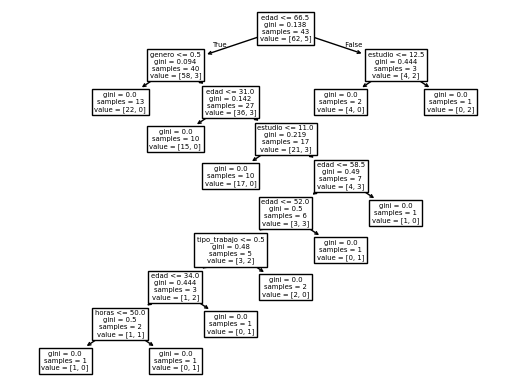

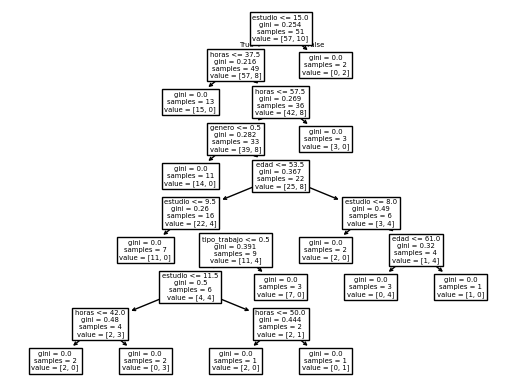

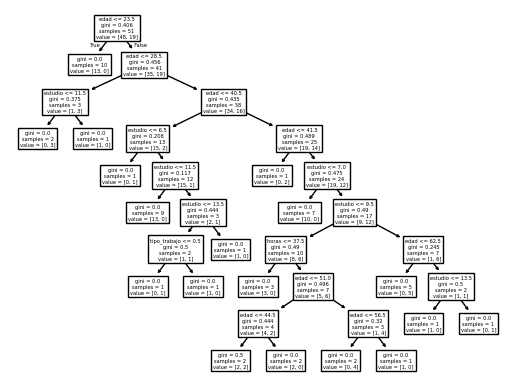

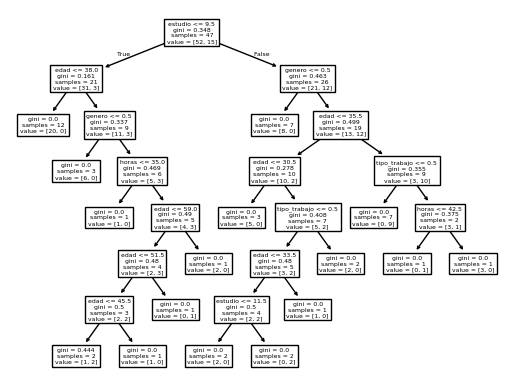

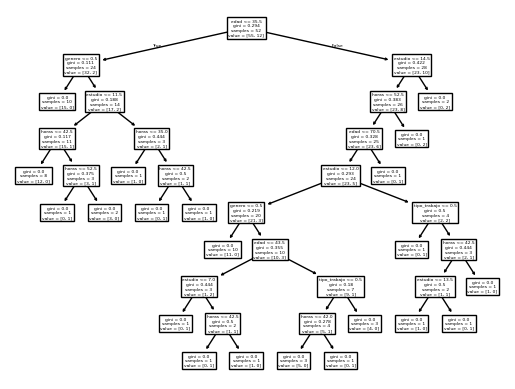

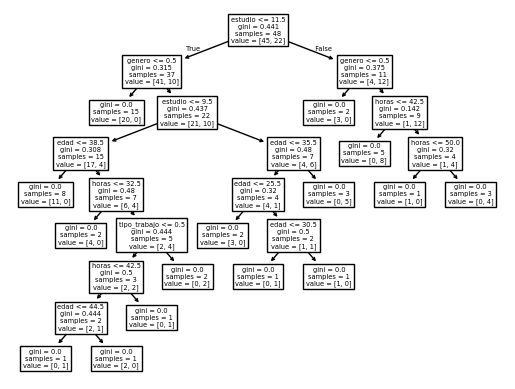

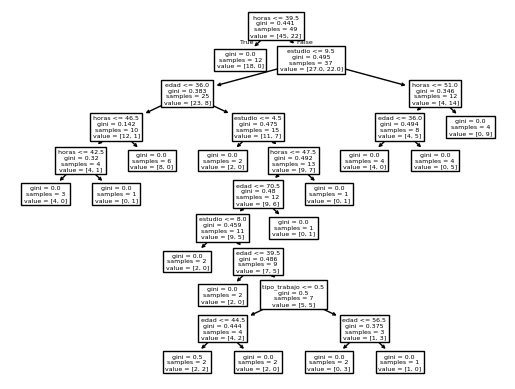

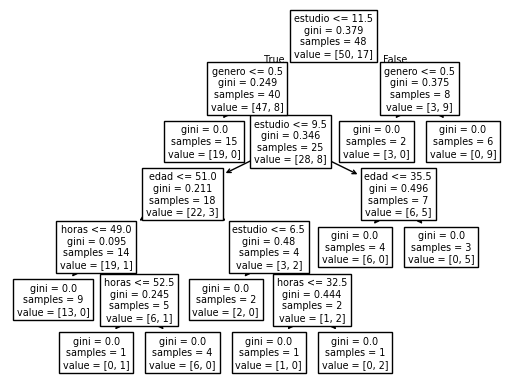

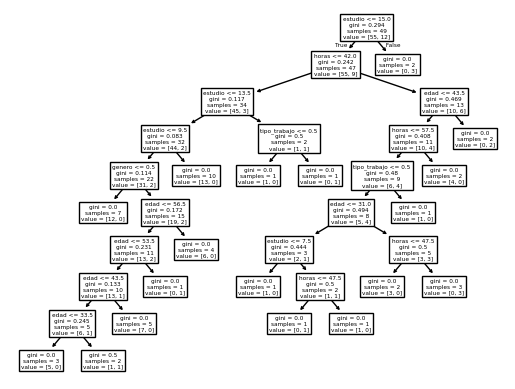

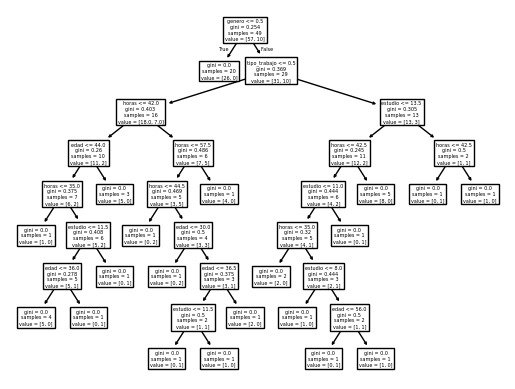

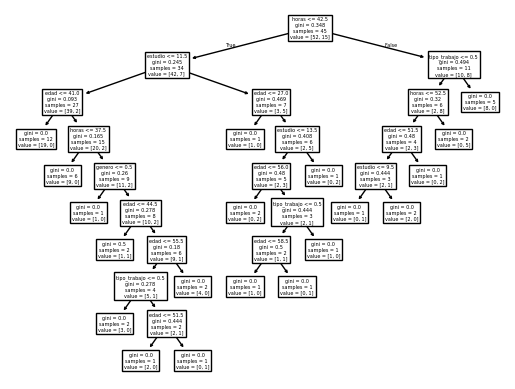

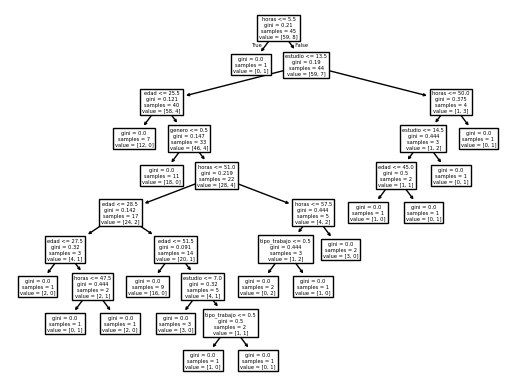

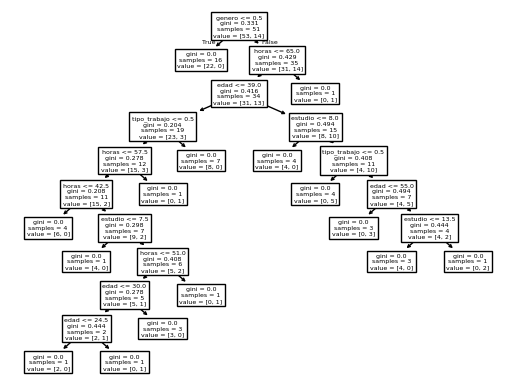

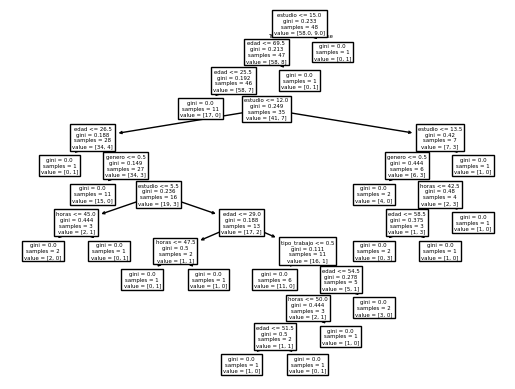

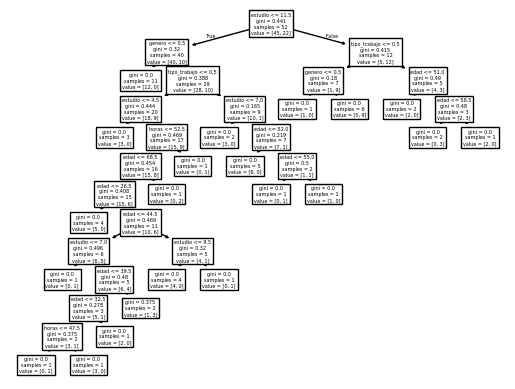

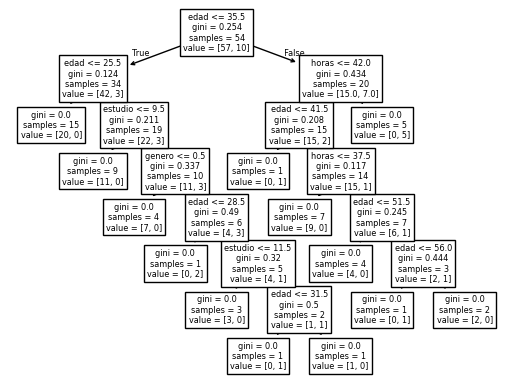

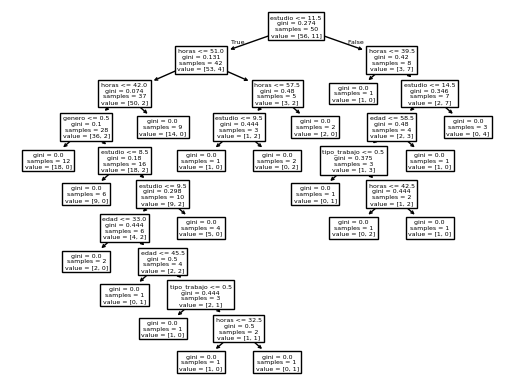

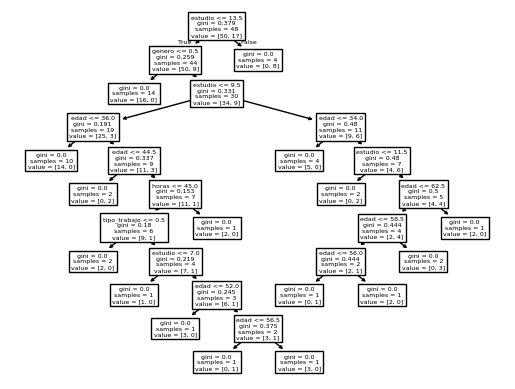

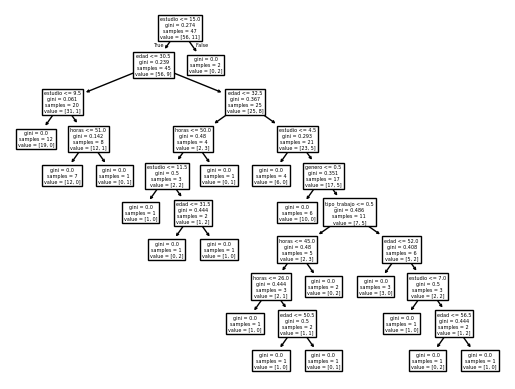

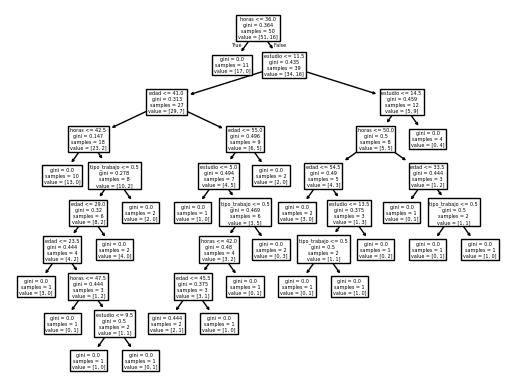

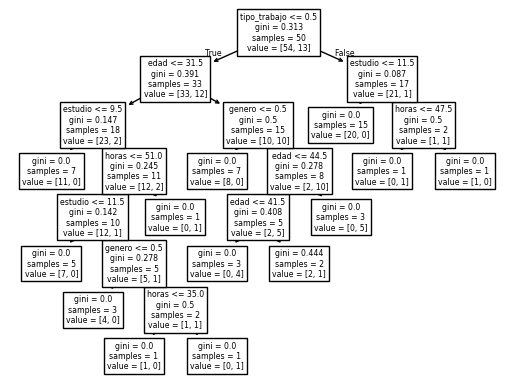

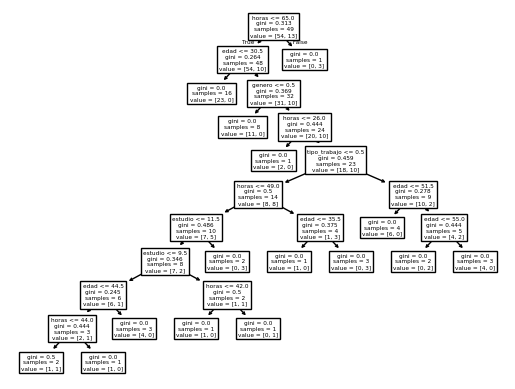

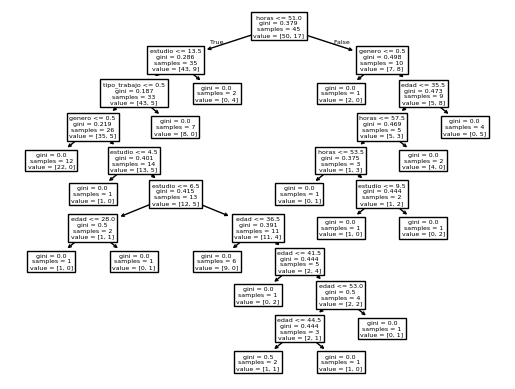

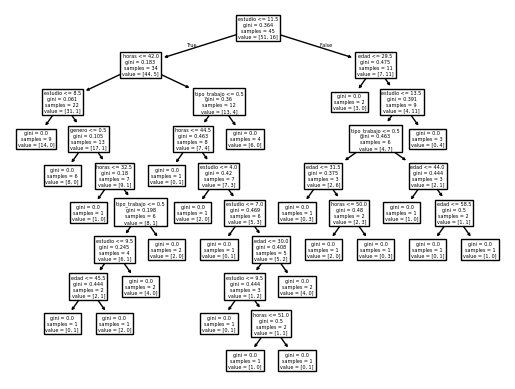

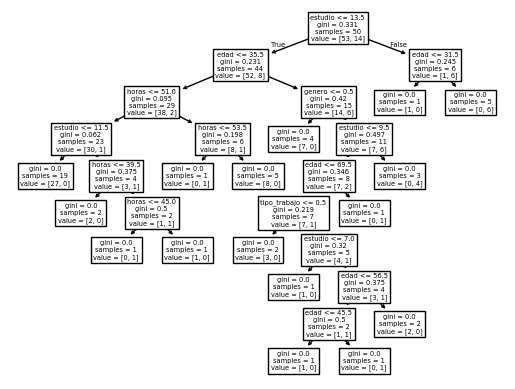

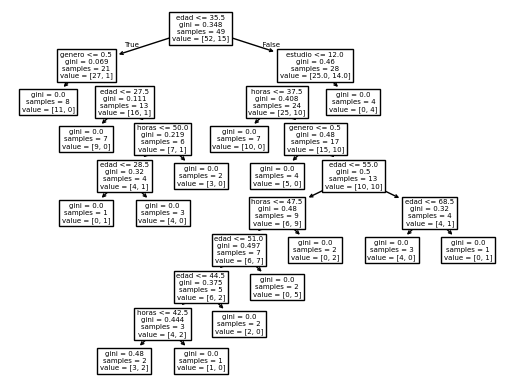

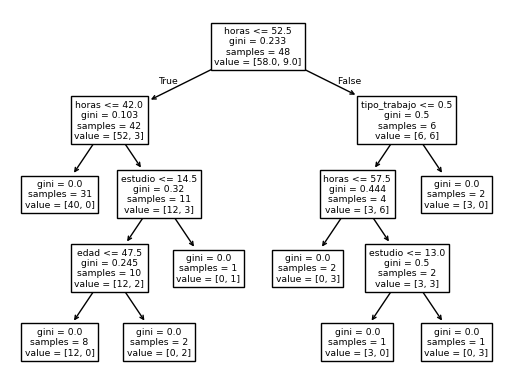

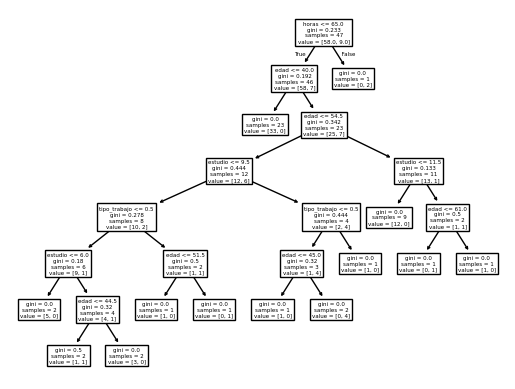

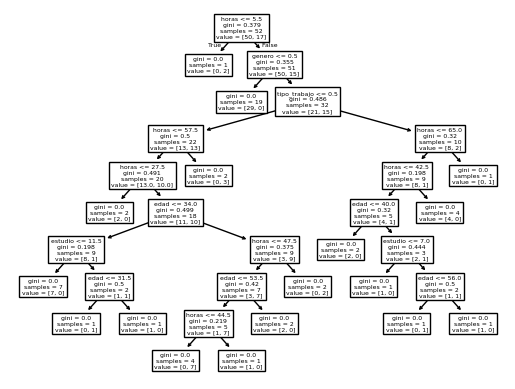

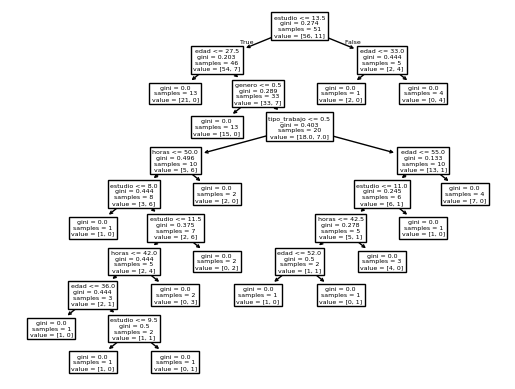

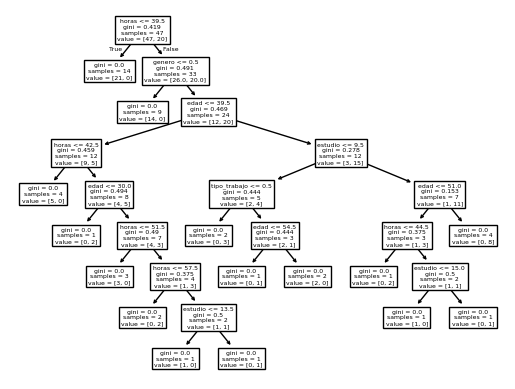

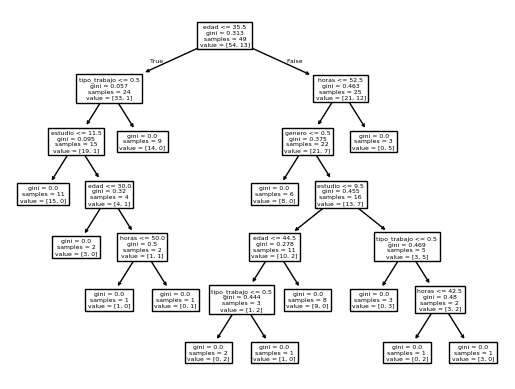

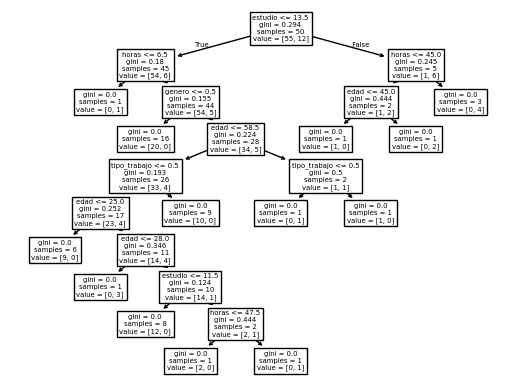

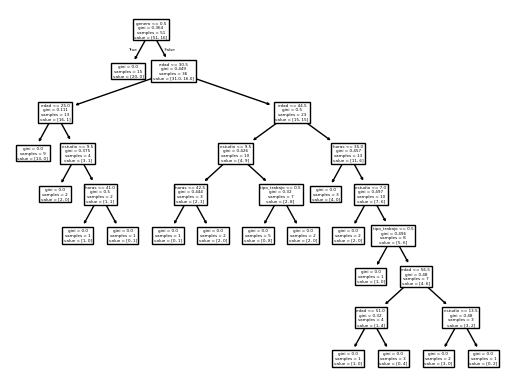

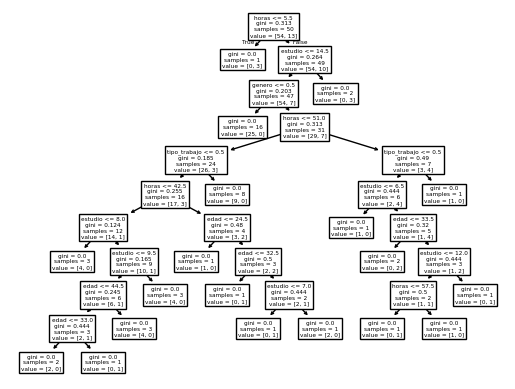

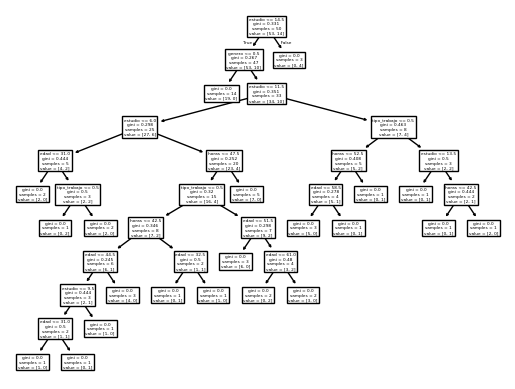

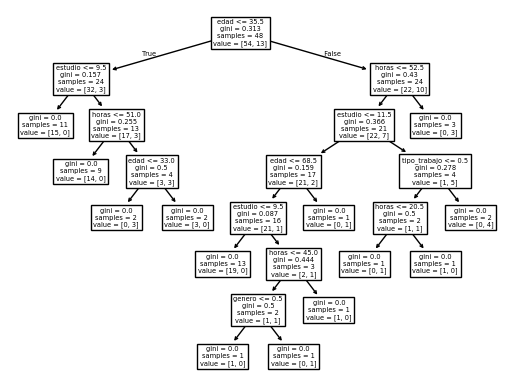

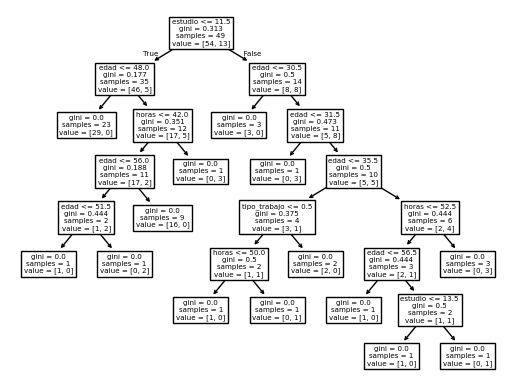

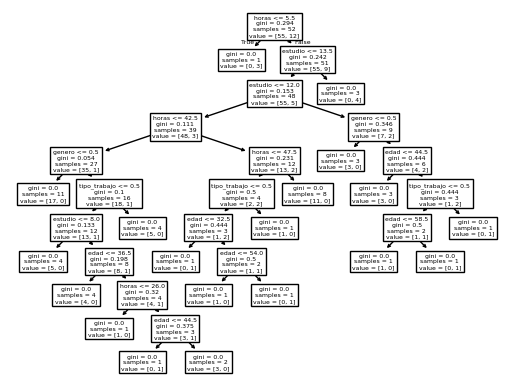

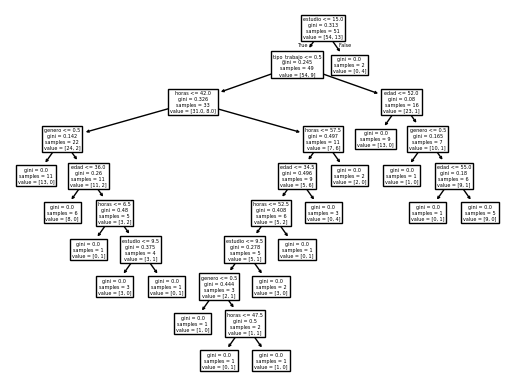

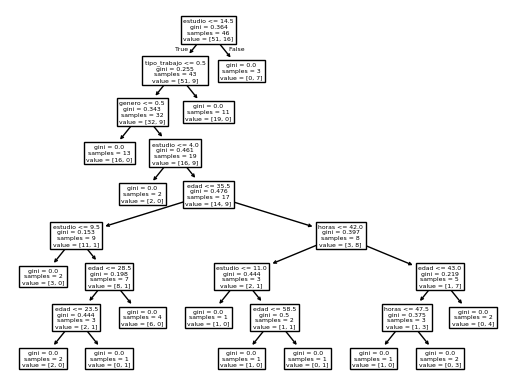

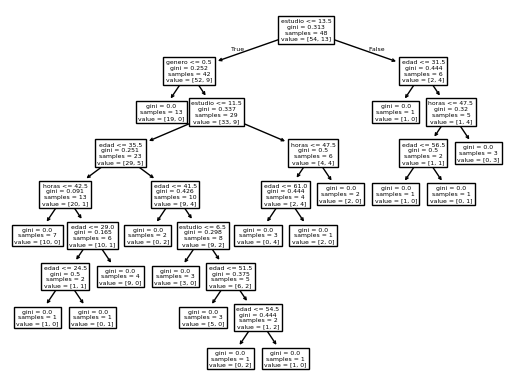

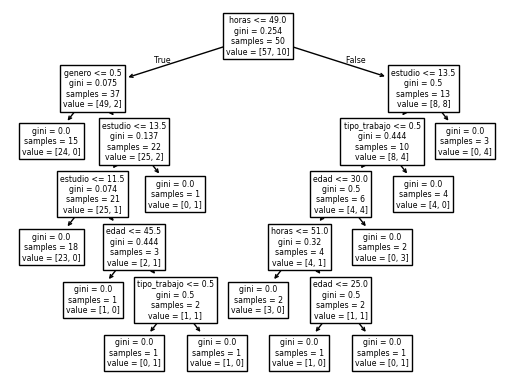

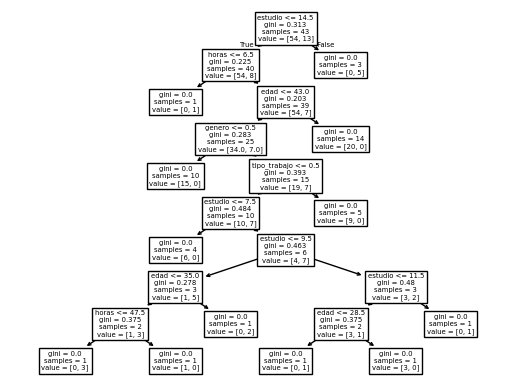

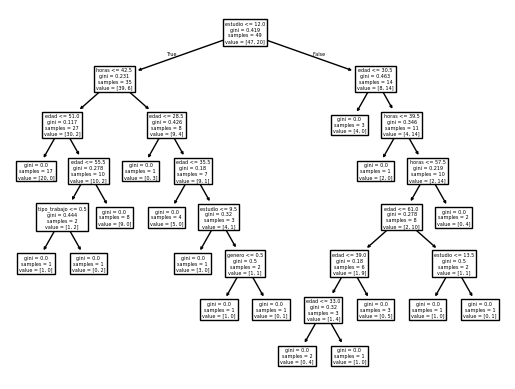

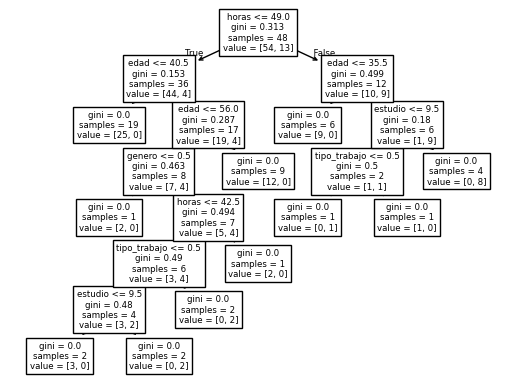

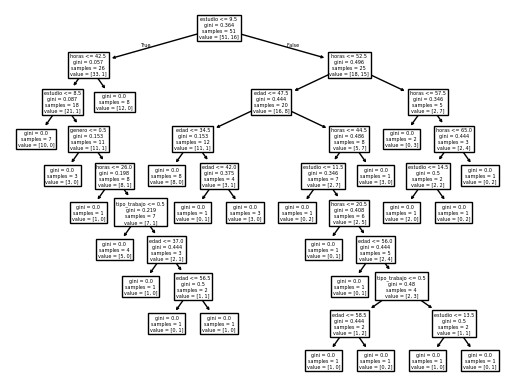

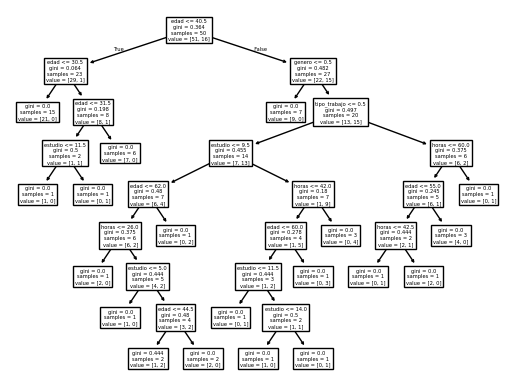

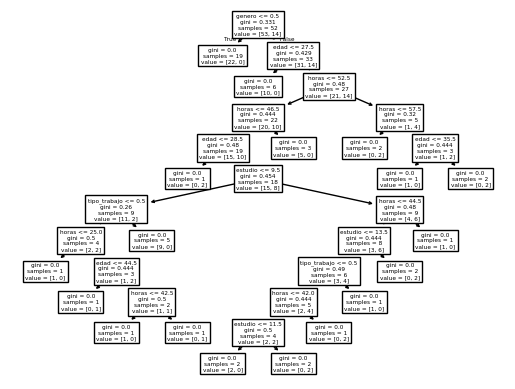

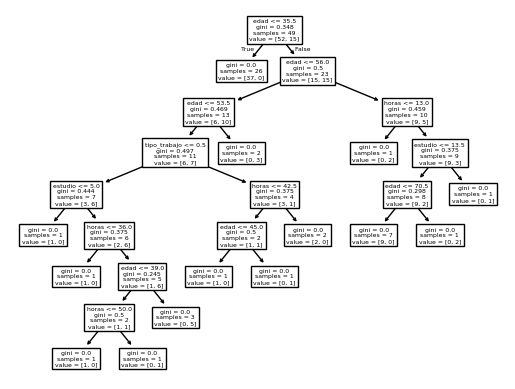

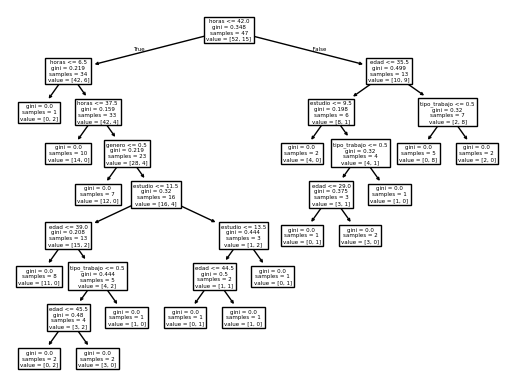

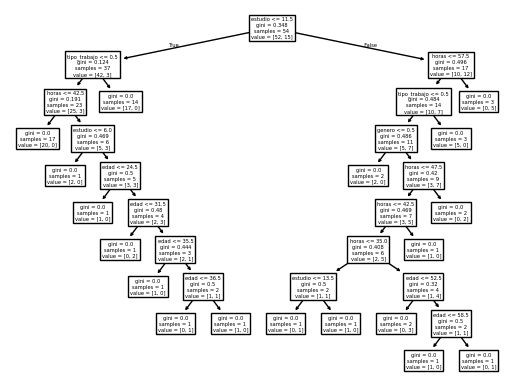

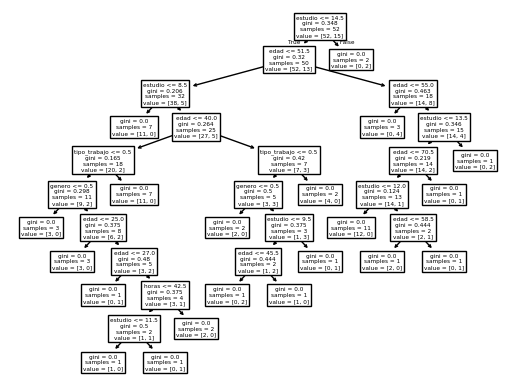

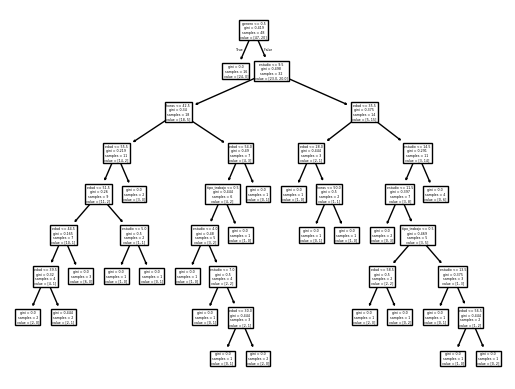

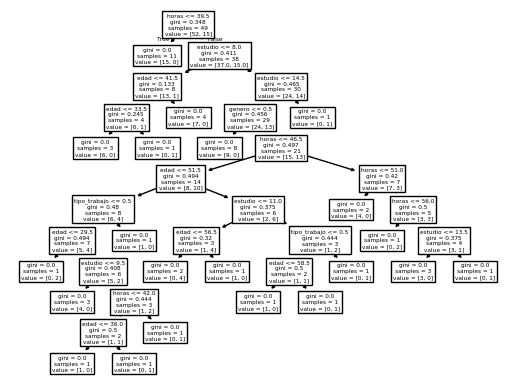

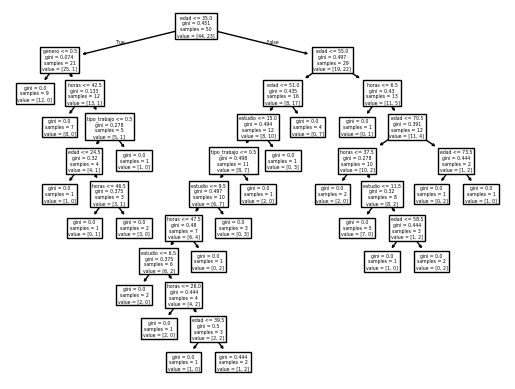

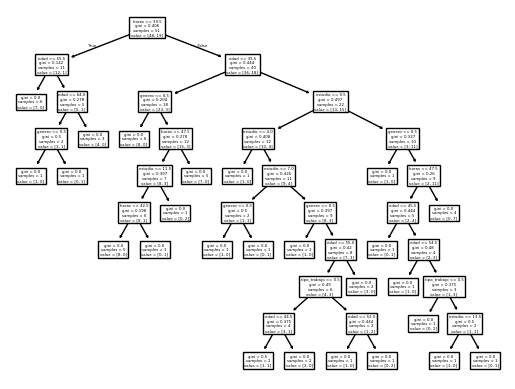

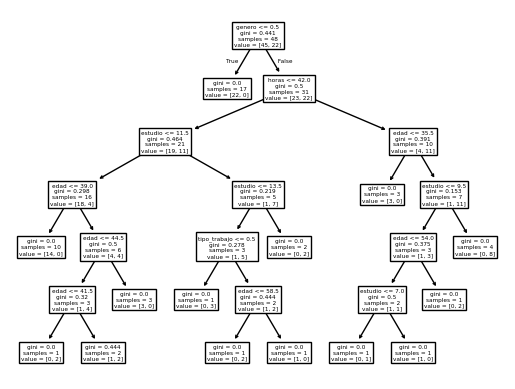

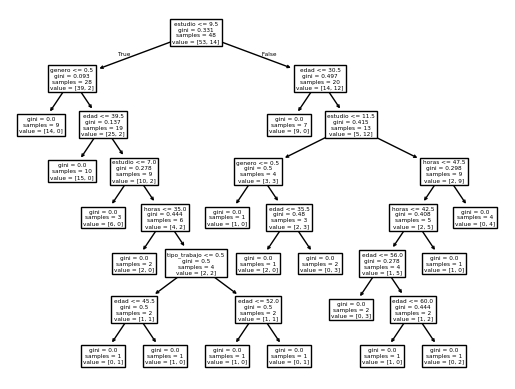

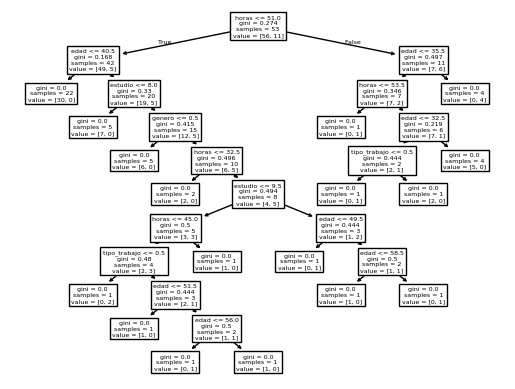

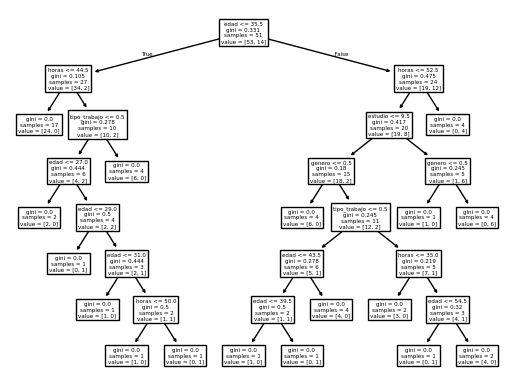

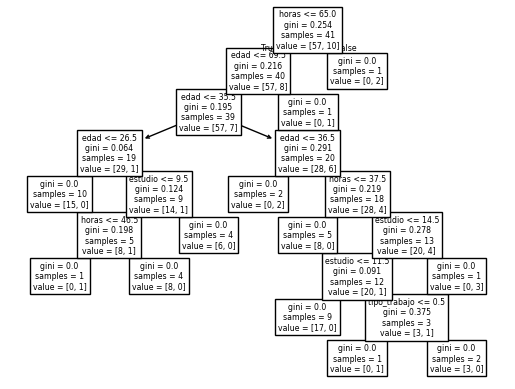

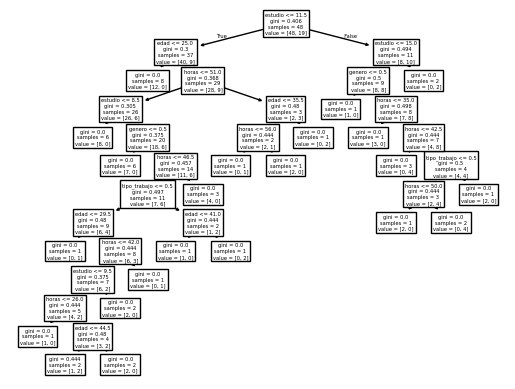

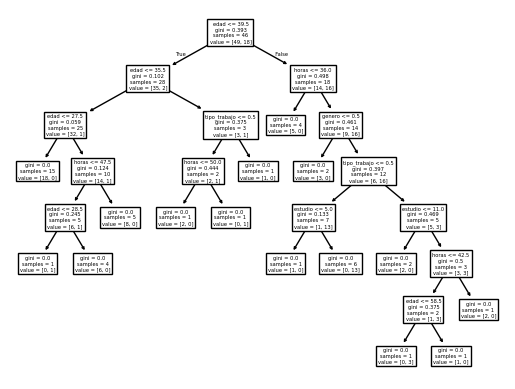

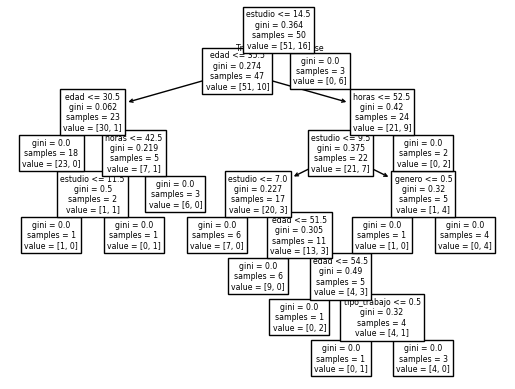

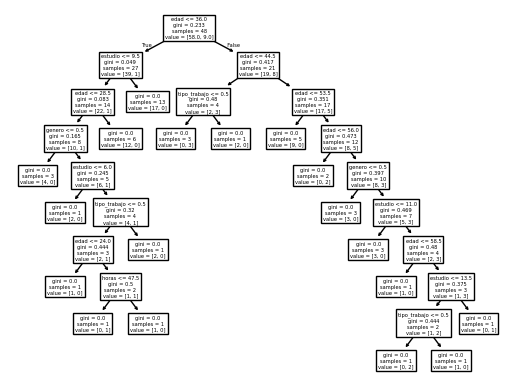

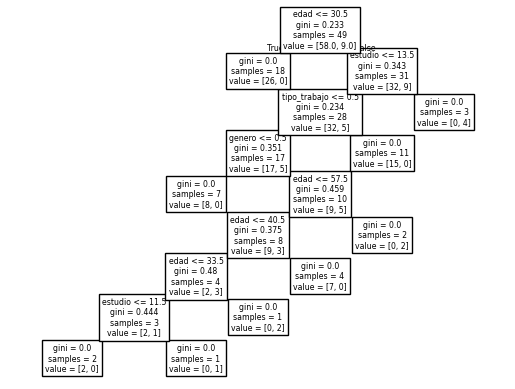

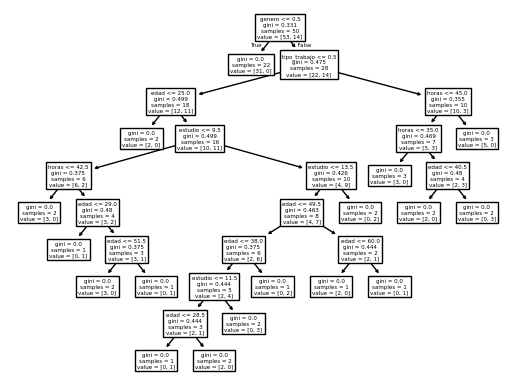

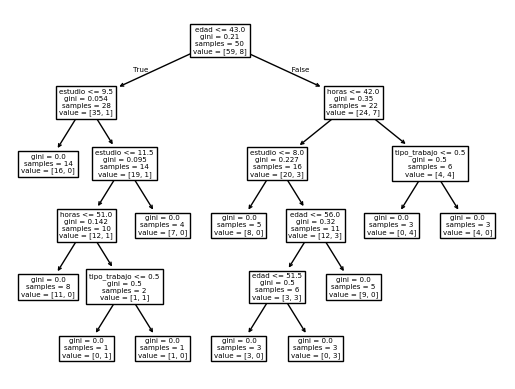

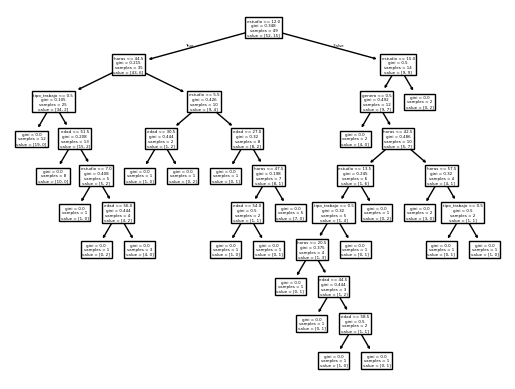

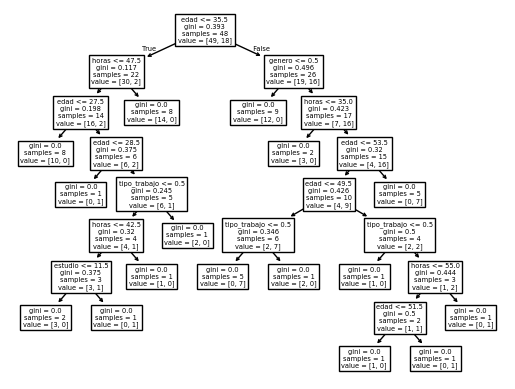

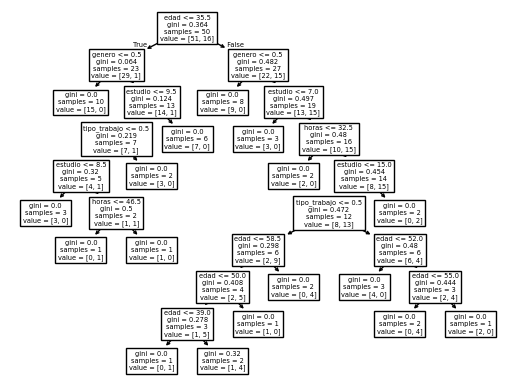

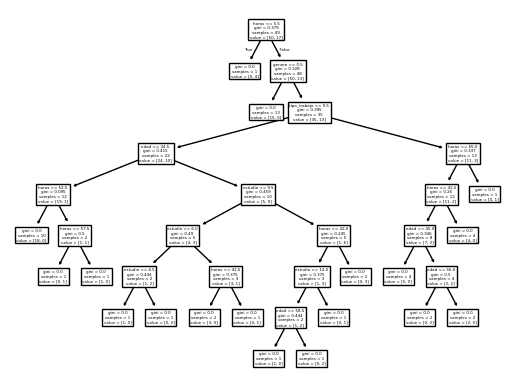

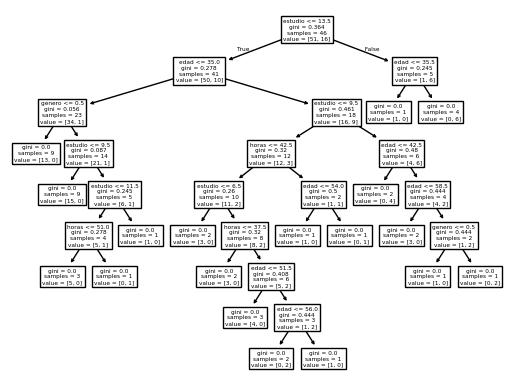

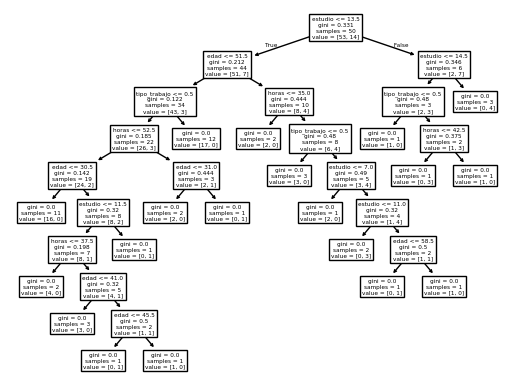

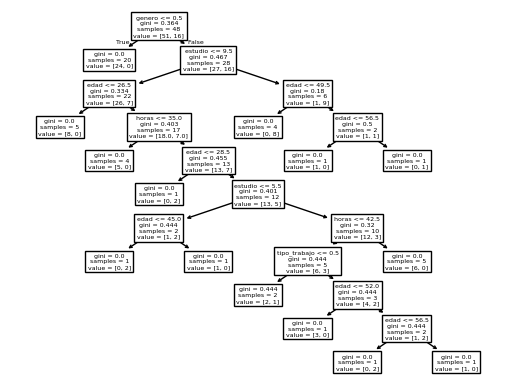

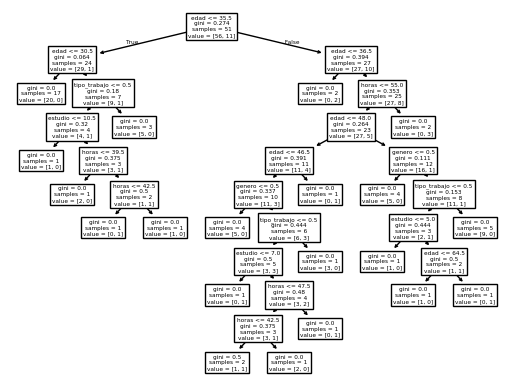

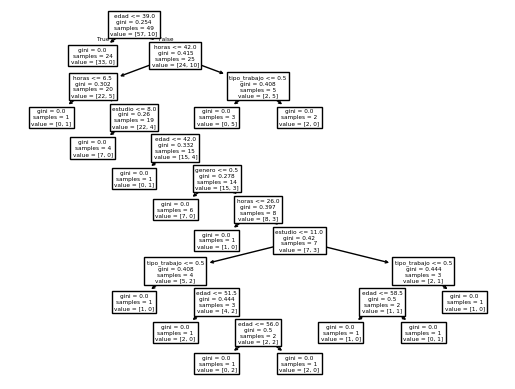

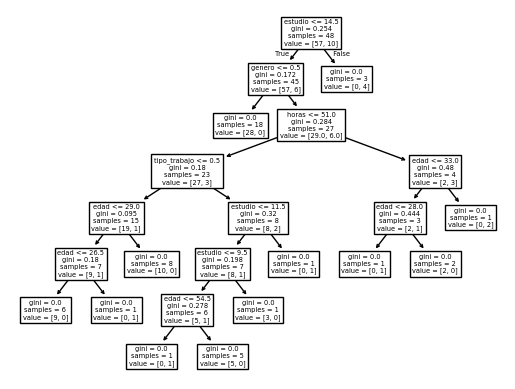

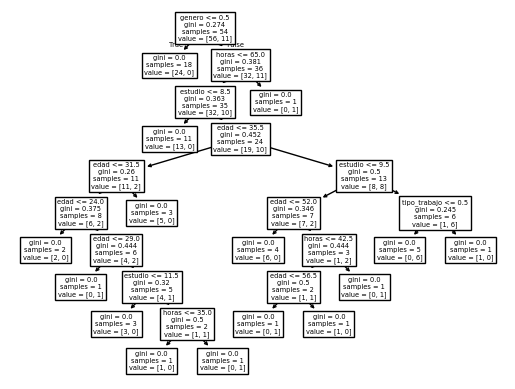

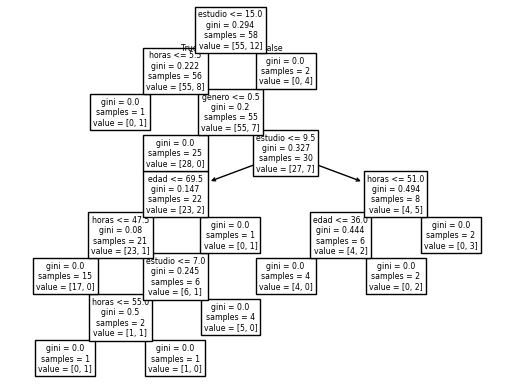

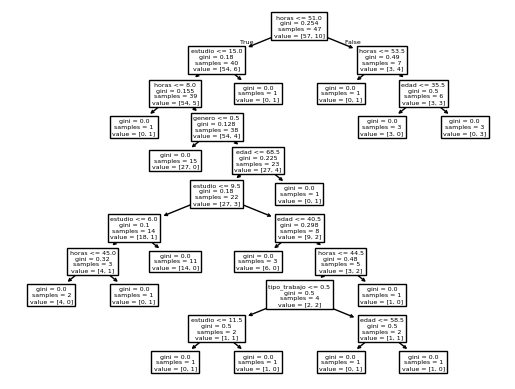

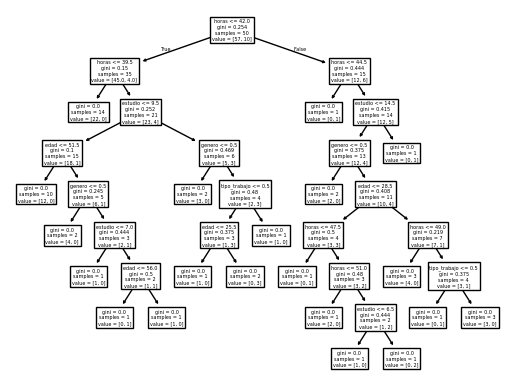

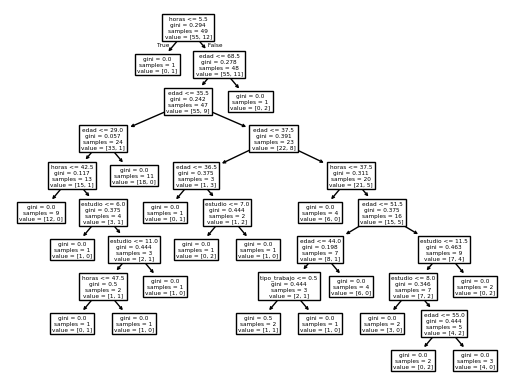

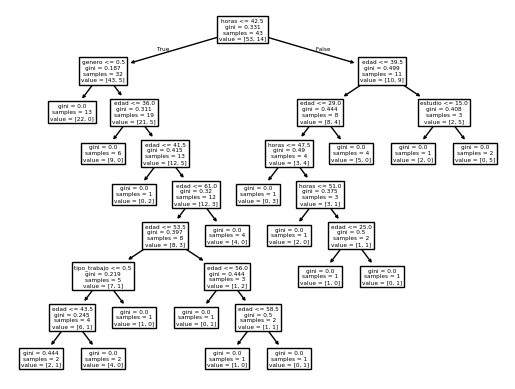

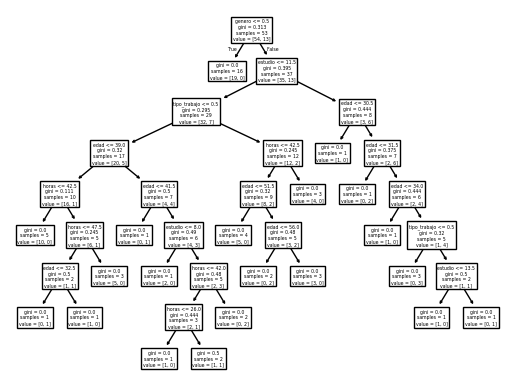

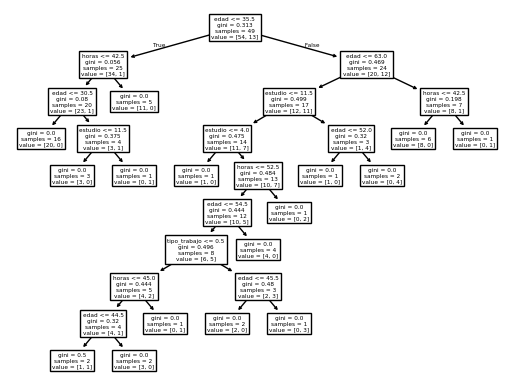

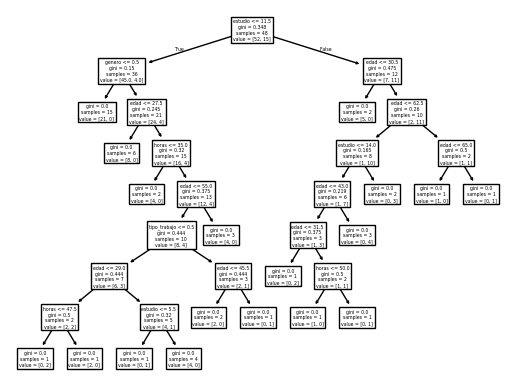

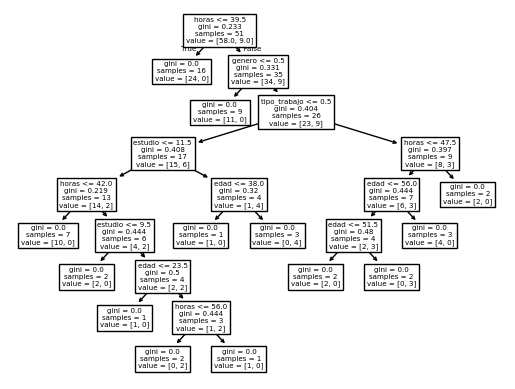

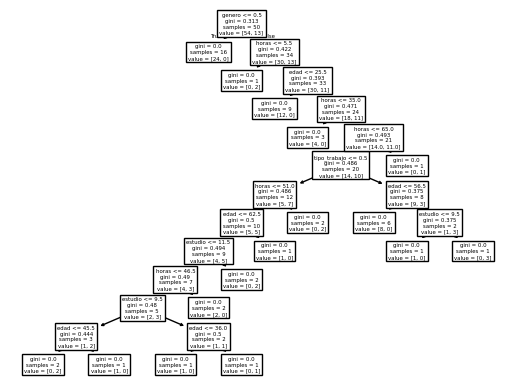

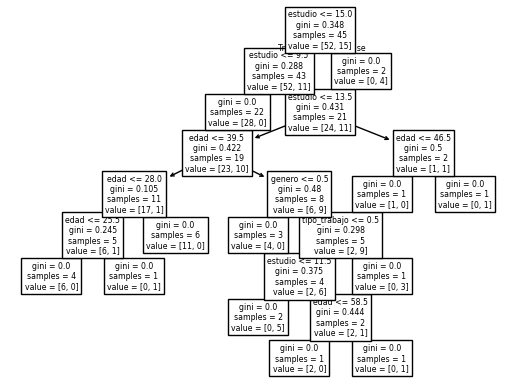

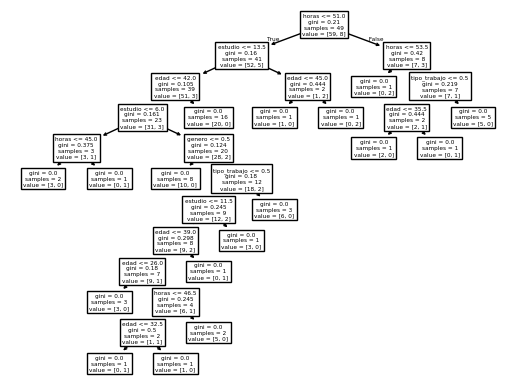

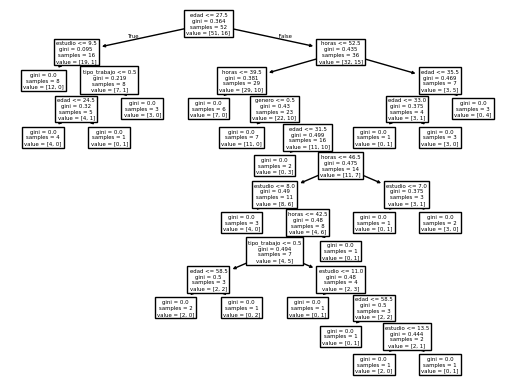

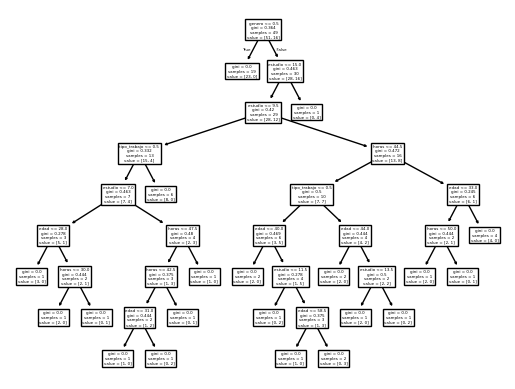

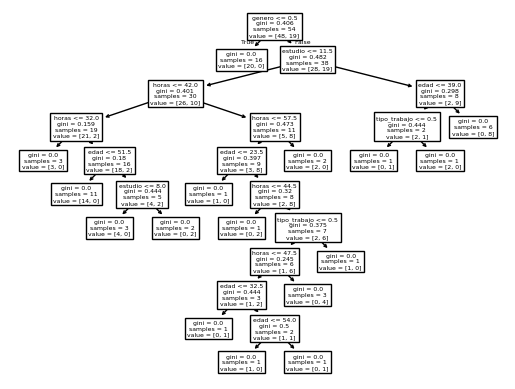

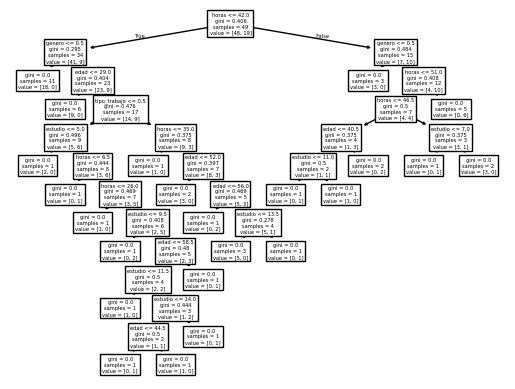

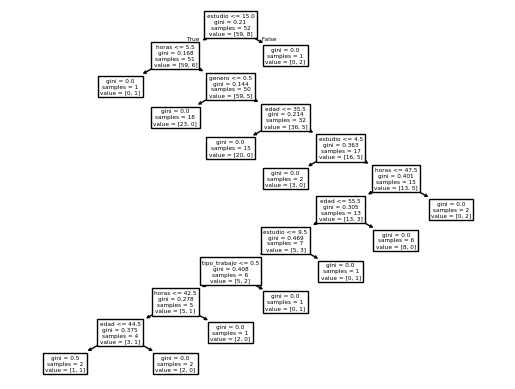

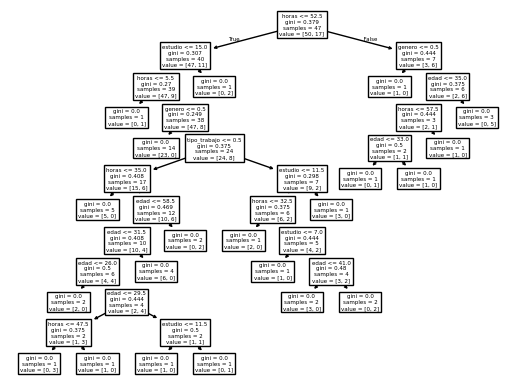

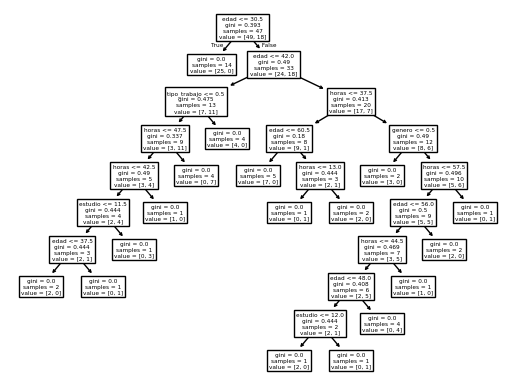

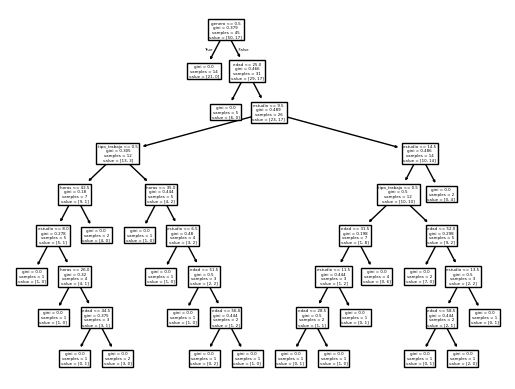

In [5]:
import matplotlib.pyplot as plt
from sklearn import tree


for arbol in bosque.estimators_:
    tree.plot_tree(arbol, feature_names=personas.columns[:-1])
    plt.show()